# Importamos las librerias
Ahora Usamos esta función debido a que tuve demasiadas complicaciones al momento de seleccionar la imagen, o subirla al drive, entonces de esta manera se puede seleccionar la imagen de manera local y guardarla en el collab

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

#Cargar Imágen
print("Selecciona tu imagen médica ")
uploaded = files.upload()
nombre_archivo = list(uploaded.keys())[0]

# Leer la imagen en escala de grises
imagen = cv2.imread(nombre_archivo, cv2.IMREAD_GRAYSCALE)

# Verificación de que la imagen se cargó correctamente
if imagen is None:
    print("Error, No se Cargo el Archivo, seleccionar de nuevo")
else:
    alto, ancho = imagen.shape
    print(f"Imagen cargada: {nombre_archivo} ({ancho}x{alto} píxeles)")

Selecciona tu imagen médica 


Saving RM_2_TX.jpeg to RM_2_TX (2).jpeg
Imagen cargada: RM_2_TX (2).jpeg (630x630 píxeles)


# Funciones de Traslación
Aquí usamos las funciones de traslacion a la imagen original, es decir moverla en el eje "X" y "Y"

In [ ]:
    # Traslación 50,30
    tx1, ty1 = 50, 30
    M1 = np.float32([[1, 0, tx1], [0, 1, ty1]])
    img_entera = cv2.warpAffine(imagen, M1, (ancho, alto))

    # Traslacion decimal 20.5 y 15.5
    tx2, ty2 = 20.5, 15.5
    M2 = np.float32([[1, 0, tx2], [0, 1, ty2]])
    # Usamos INTER_LINEAR para que el movimiento decimal sea suave
    img_decimal = cv2.warpAffine(imagen, M2, (ancho, alto), flags=cv2.INTER_LINEAR)



# Resultados
Finalmente Ponemos las funciones para mostras las imagenes procesadas con la traslación.

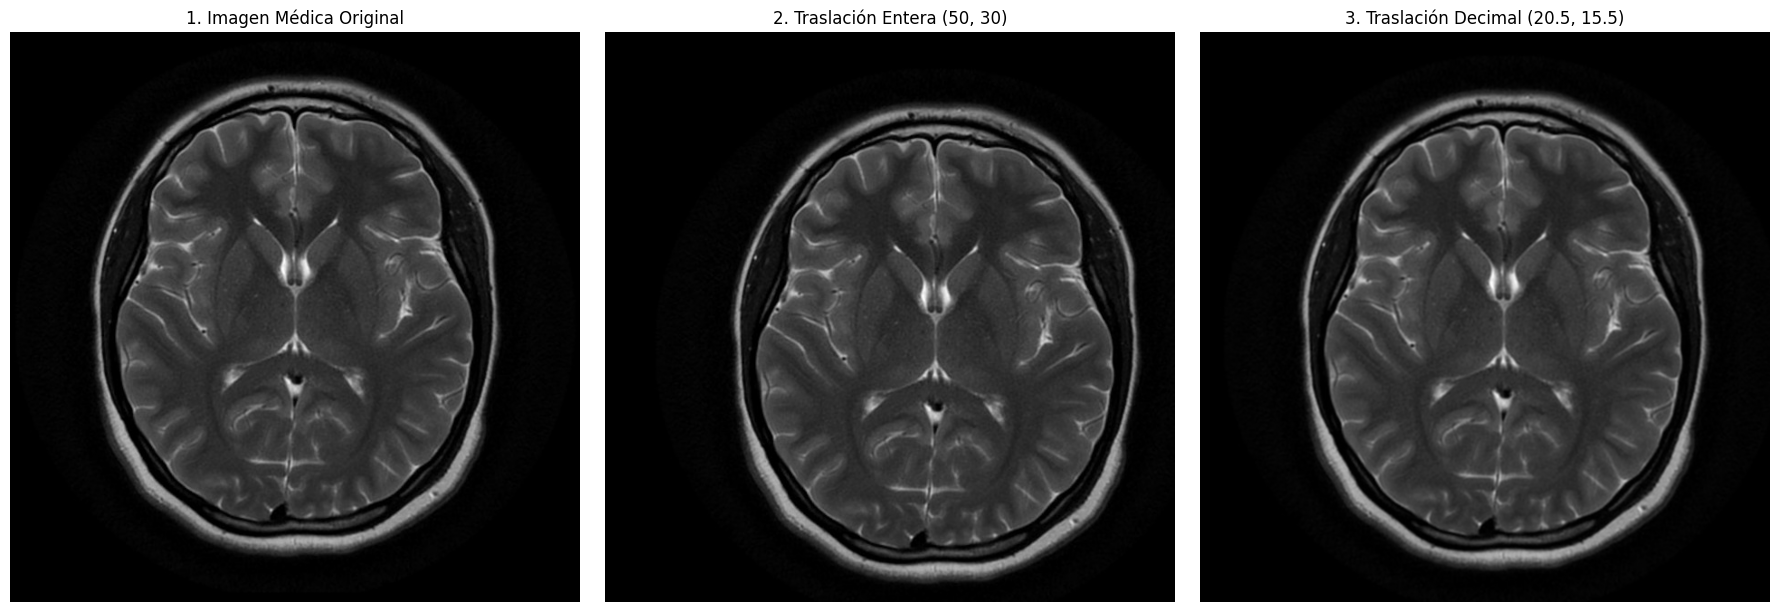

In [ ]:
# MOSTRAR RESULTADOS
plt.figure(figsize=(18, 6))

# Imagen Original
plt.subplot(1, 3, 1)
plt.imshow(imagen, cmap="gray")
plt.title("1. Imagen Médica Original")
plt.axis("off")

# Traslación Entera
plt.subplot(1, 3, 2)
plt.imshow(img_entera, cmap="gray")
plt.title(f"2. Traslación Entera ({tx1}, {ty1})")
plt.axis("off")

# Traslación Decimal
plt.subplot(1, 3, 3)
plt.imshow(img_decimal, cmap="gray")
plt.title(f"3. Traslación Decimal ({tx2}, {ty2})")
plt.axis("off")

plt.tight_layout()
plt.show()

# EJERCICIO 2
En este ejercicio tenemos que aplicarle una rotacion de 45° al centro de la imagen.

Importamos las librerias y al igual que con el ejercicio uno la función para cargar la imagen directamente desde nuestro ordenador

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# --- PASO 1: CARGAR LA IMAGEN ---
print("Selecciona tu imagen médica (JPG, PNG, etc.):")
uploaded = files.upload()

# Verificar si se subió algún archivo
if not uploaded:
    print("No se seleccionó ningún archivo.")
else:
    nombre_archivo = list(uploaded.keys())[0]

    # Leer la imagen en escala de grises
    imagen = cv2.imread(nombre_archivo, cv2.IMREAD_GRAYSCALE)

    # Verificación de que la imagen se cargó correctamente
    if imagen is None:
        print("Error: No se pudo leer el archivo. Intenta subirlo de nuevo.")
    else:
        alto, ancho = imagen.shape
        print(f"Imagen cargada: {nombre_archivo} ({ancho}x{alto} píxeles)")



Selecciona tu imagen médica (JPG, PNG, etc.):


Saving RM_2_TX.jpeg to RM_2_TX (4).jpeg
Imagen cargada: RM_2_TX (4).jpeg (630x630 píxeles)


# Procesamiento
Aquí aplicamos la traslación de la imagen y la rotación de esta misma en 45° como el ejrcicio nos lo pide


In [ ]:
        # Traslación
        tx, ty = 50, 30
        M_traslacion = np.float32([[1, 0, tx], [0, 1, ty]])
        # Se aplica la traslación a la imagen original
        img_trasladada = cv2.warpAffine(imagen, M_traslacion, (ancho, alto))

        # Rotación de 45°
        # Calcular el centro de la imagen
        centro = (ancho // 2, alto // 2)
        angulo = 45
        escala = 1.0 # Mantenemos el tamaño original

        # Generar la matriz de rotación
        M_rotacion = cv2.getRotationMatrix2D(centro, angulo, escala)

        # Aplicar la rotación a la imagen original
        img_rotada = cv2.warpAffine(imagen, M_rotacion, (ancho, alto))


## Resultados
Creamos el codigo para la salida de nuestras imagenes, tanto la original, como la trasladada como la trasladada y rotada


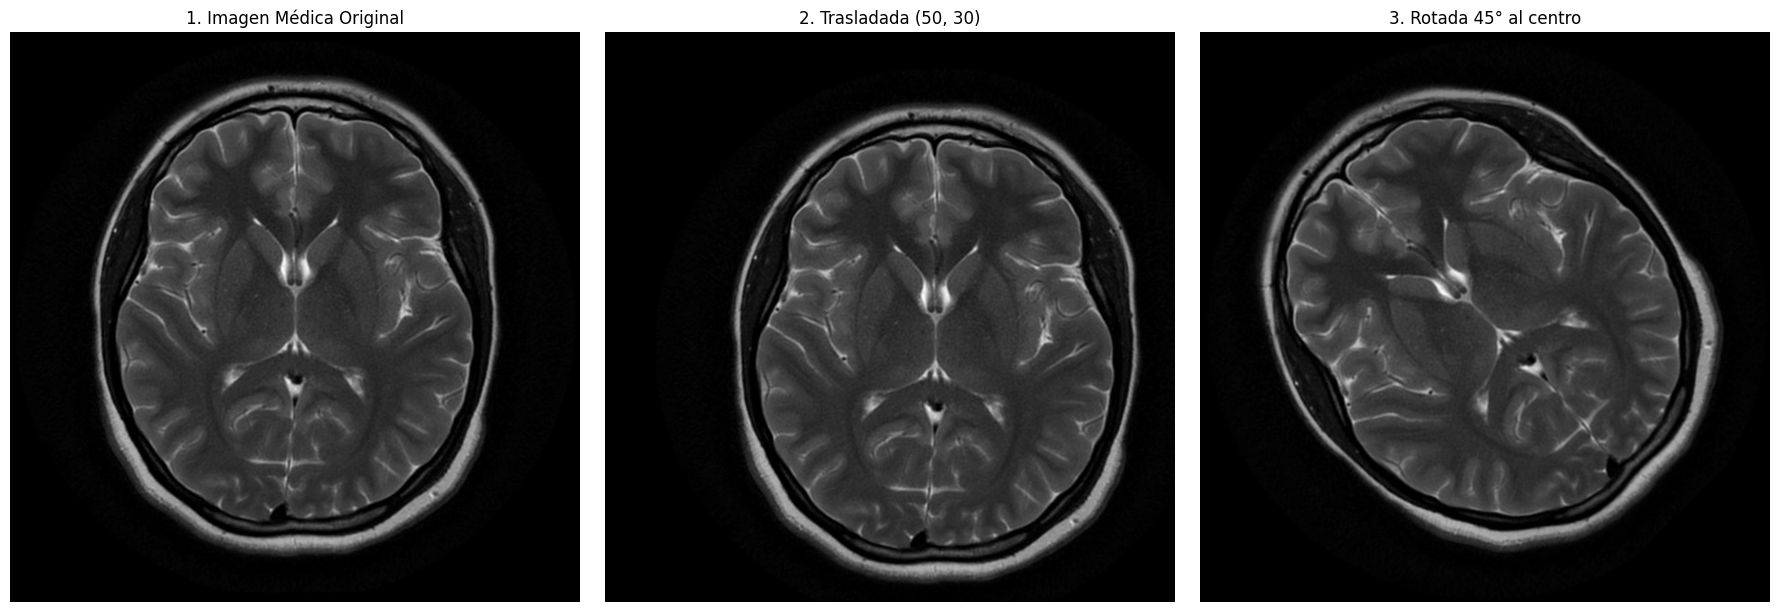

In [ ]:
        # Resultados
        plt.figure(figsize=(18, 6))

        # 1. Imagen Original
        plt.subplot(1, 3, 1)
        plt.imshow(imagen, cmap="gray")
        plt.title("1. Imagen Médica Original")
        plt.axis("off")

        # 2. Imagen Trasladada
        plt.subplot(1, 3, 2)
        plt.imshow(img_trasladada, cmap="gray")
        plt.title(f"2. Trasladada ({tx}, {ty})")
        plt.axis("off")

        # 3. Imagen Rotada
        plt.subplot(1, 3, 3)
        plt.imshow(img_rotada, cmap="gray")
        plt.title(f"3. Rotada {angulo}° al centro")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

# EJERCICIO 3
Aquí tenemos que aplicar un escalado del 150% y otro del 50%

Selecciona tu imagen médica (JPG, PNG, etc.):


Saving RM_TUMOR.jpg to RM_TUMOR (2).jpg
Imagen cargada: RM_TUMOR (2).jpg (177x197 píxeles)


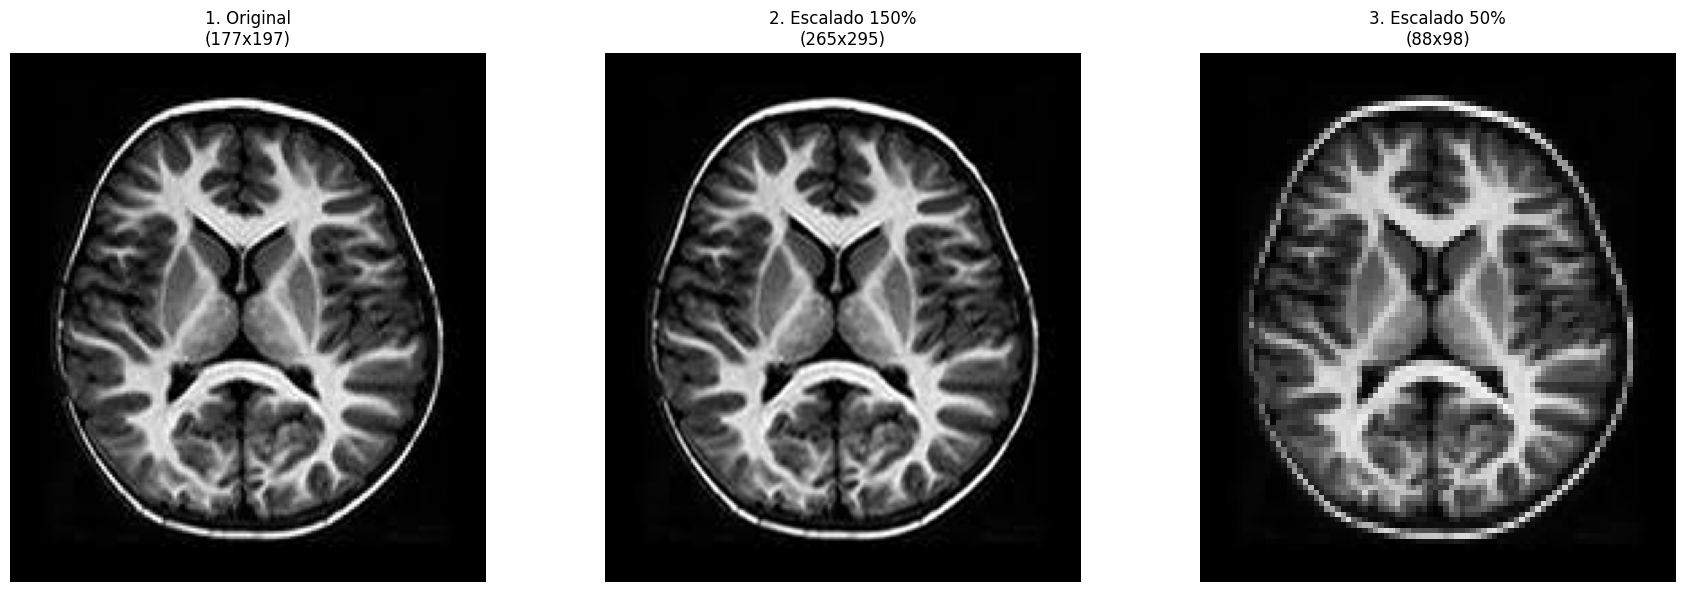

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# --- PASO 1: CARGAR LA IMAGEN ---
print("Selecciona tu imagen médica (JPG, PNG, etc.):")
uploaded = files.upload()

# Verificar si se subió algún archivo
if not uploaded:
    print("No se seleccionó ningún archivo.")
else:
    nombre_archivo = list(uploaded.keys())[0]

    # Leer la imagen en escala de grises
    imagen = cv2.imread(nombre_archivo, cv2.IMREAD_GRAYSCALE)

    # Verificación de que la imagen se cargó correctamente
    if imagen is None:
        print("Error: No se pudo leer el archivo. Intenta subirlo de nuevo.")
    else:
        # Obtener dimensiones originales
        alto, ancho = imagen.shape
        print(f"Imagen cargada: {nombre_archivo} ({ancho}x{alto} píxeles)")

        # Escalado al 150%
        nuevo_ancho_150 = int(ancho * 1.5)
        nuevo_alto_150 = int(alto * 1.5)
        imagen_150 = cv2.resize(imagen, (nuevo_ancho_150, nuevo_alto_150), interpolation=cv2.INTER_CUBIC)

        # Escalado al 50%
        nuevo_ancho_50 = int(ancho * 0.5)
        nuevo_alto_50 = int(alto * 0.5)
        imagen_50 = cv2.resize(imagen, (nuevo_ancho_50, nuevo_alto_50), interpolation=cv2.INTER_AREA)

        # Resultados
        plt.figure(figsize=(18, 6))

        # 1. Imagen Original
        plt.subplot(1, 3, 1)
        plt.imshow(imagen, cmap="gray")
        plt.title(f"1. Original\n({ancho}x{alto})")
        plt.axis("off")

        # 2. Imagen al 150%
        plt.subplot(1, 3, 2)
        plt.imshow(imagen_150, cmap="gray")
        plt.title(f"2. Escalado 150%\n({nuevo_ancho_150}x{nuevo_alto_150})")
        plt.axis("off")

        # 3. Imagen al 50%
        plt.subplot(1, 3, 3)
        plt.imshow(imagen_50, cmap="gray")
        plt.title(f"3. Escalado 50%\n({nuevo_ancho_50}x{nuevo_alto_50})")
        plt.axis("off")

        plt.tight_layout()
        plt.show()